## Plots for the group project


In [1]:
import plotters as pl
import pandas as pd
import numpy as np
import helper_functions as hf

In [2]:
cv_prm_df_t = pd.read_csv("datasets/cv_prm_t.csv")
cv_prm_df_n = pd.read_csv("datasets/cv_prm_n.csv")

vv_prm_df_t = pd.read_csv("datasets/vv_prm_t.csv")
vv_prm_df_n = pd.read_csv("datasets/vv_prm_n.csv")

cv_rft_df_t = pd.read_csv("datasets/cv_rft_t.csv")
cv_rft_df_n = pd.read_csv("datasets/cv_rft_n.csv")

vv_rft_df_t = pd.read_csv("datasets/vv_rft_t.csv")
vv_rft_df_n = pd.read_csv("datasets/vv_rft_n.csv")

bonferroni_df_t = pd.read_csv("datasets/bonferroni_t.csv")
bonferroni_df_n = pd.read_csv("datasets/bonferroni_n.csv")

In [3]:
cv_prm_df_t["method"] = "Cluster-wise permutation"
cv_prm_df_t["distribution"] = "t"

cv_prm_df_n["method"] = "Cluster-wise permutation"
cv_prm_df_n["distribution"] = "normal"



cv_rft_df_t["method"] = "Cluster-wise RFT"
cv_rft_df_t["distribution"] = "t"

cv_rft_df_n["method"] = "Cluster-wise RFT"
cv_rft_df_n["distribution"] = "normal"



vv_prm_df_t["method"] = "Voxel-wise permutation"
vv_prm_df_t["distribution"] = "t"

vv_prm_df_n["method"] = "Voxel-wise permutation"
vv_prm_df_n["distribution"] = "normal"

In [4]:
bonferroni_df_t.head()

,fwer,sensitivity,sm_sigma,snr,n,method,distribution
0,0.050667,0.000000,0.0,0.00,2,Bonferroni,t
1,0.038667,0.000012,0.0,0.10,2,Bonferroni,t
2,0.038667,0.000000,0.0,0.25,2,Bonferroni,t
3,0.038667,0.000035,0.0,0.50,2,Bonferroni,t
4,0.033333,0.000047,0.0,0.75,2,Bonferroni,t


In [5]:
cv_rft_df_n.rename(columns={"n_subj" : "n", "FWER" : "fwer"}, inplace=True)
cv_rft_df_t.rename(columns={"n_subj" : "n", "FWER" : "fwer"}, inplace=True)

cv_rft_df_n.drop(['FWHM','threshold_u'],axis=1, inplace=True)
cv_rft_df_t.drop(['FWHM','threshold_u'],axis=1, inplace=True)


cv_rft_df_n.head()

,fwer,sensitivity,sm_sigma,snr,n,method,distribution
0,0.0,0.0,0.0,0.0,2,Cluster-wise RFT,normal
1,0.0,0.0,0.0,0.0,5,Cluster-wise RFT,normal
2,0.0,0.0,0.0,0.0,7,Cluster-wise RFT,normal
3,0.0,0.0,0.0,0.0,10,Cluster-wise RFT,normal
4,0.0,0.0,0.0,0.0,15,Cluster-wise RFT,normal


In [6]:
vv_prm_df_n.head()

,fwer,sensitivity,sm_sigma,snr,n,method,distribution
0,0.0,0.0,0.0,0.00,2,Voxel-wise permutation,normal
1,0.0,0.0,0.0,0.10,2,Voxel-wise permutation,normal
2,0.0,0.0,0.0,0.25,2,Voxel-wise permutation,normal
3,0.0,0.0,0.0,0.50,2,Voxel-wise permutation,normal
4,0.0,0.0,0.0,0.75,2,Voxel-wise permutation,normal


In [7]:
vv_rft_df_n.head()

,fwer,sensitivity,sm_sigma,snr,n,method
0,0.05,0.000000,0.0,0.00,2,voxelwise_rft
1,0.05,0.000000,0.0,0.10,2,voxelwise_rft
2,0.15,0.000000,0.0,0.25,2,voxelwise_rft
3,0.00,0.000000,0.0,0.50,2,voxelwise_rft
4,0.15,0.001327,0.0,0.75,2,voxelwise_rft


In [8]:
final_metrics_df_t = pd.concat([cv_prm_df_t, vv_prm_df_t, vv_rft_df_t, cv_rft_df_t, bonferroni_df_t], ignore_index=True)
final_metrics_df_n = pd.concat([cv_prm_df_n, vv_prm_df_n, vv_rft_df_n, cv_rft_df_n, bonferroni_df_n], ignore_index=True)
final_metrics_df_n.head()

,fwer,sensitivity,sm_sigma,snr,n,method,distribution
0,0.0,0.0,0.0,0.00,2,Cluster-wise permutation,normal
1,0.0,0.0,0.0,0.10,2,Cluster-wise permutation,normal
2,0.0,0.0,0.0,0.25,2,Cluster-wise permutation,normal
3,0.0,0.0,0.0,0.50,2,Cluster-wise permutation,normal
4,0.0,0.0,0.0,0.75,2,Cluster-wise permutation,normal


In [9]:
test_snrs =     [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
test_sigmas =   [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
n_values = [2,5,7,10,15,20,30,45,60]

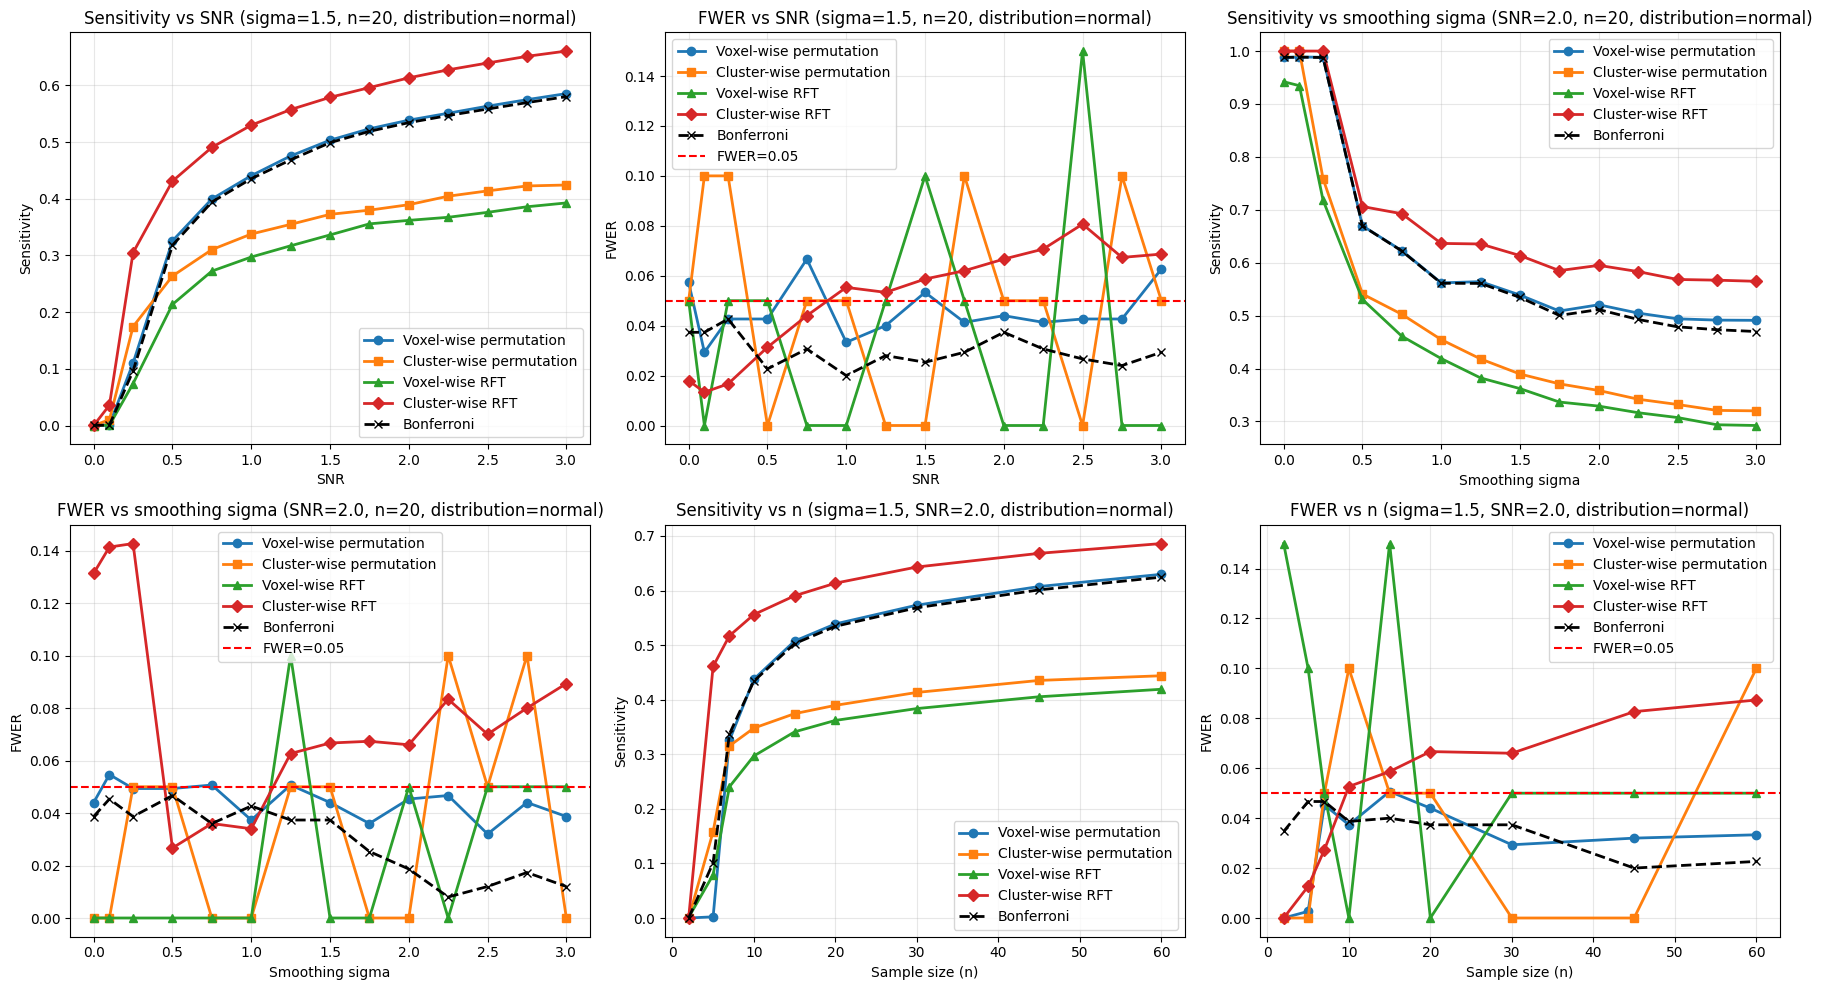

In [10]:
import importlib
import plotters as pl
importlib.reload(pl)

pl.plot_all_method_curves(final_metrics_df_n, sigma=1.5, snr_val=2.0, n_val=20)

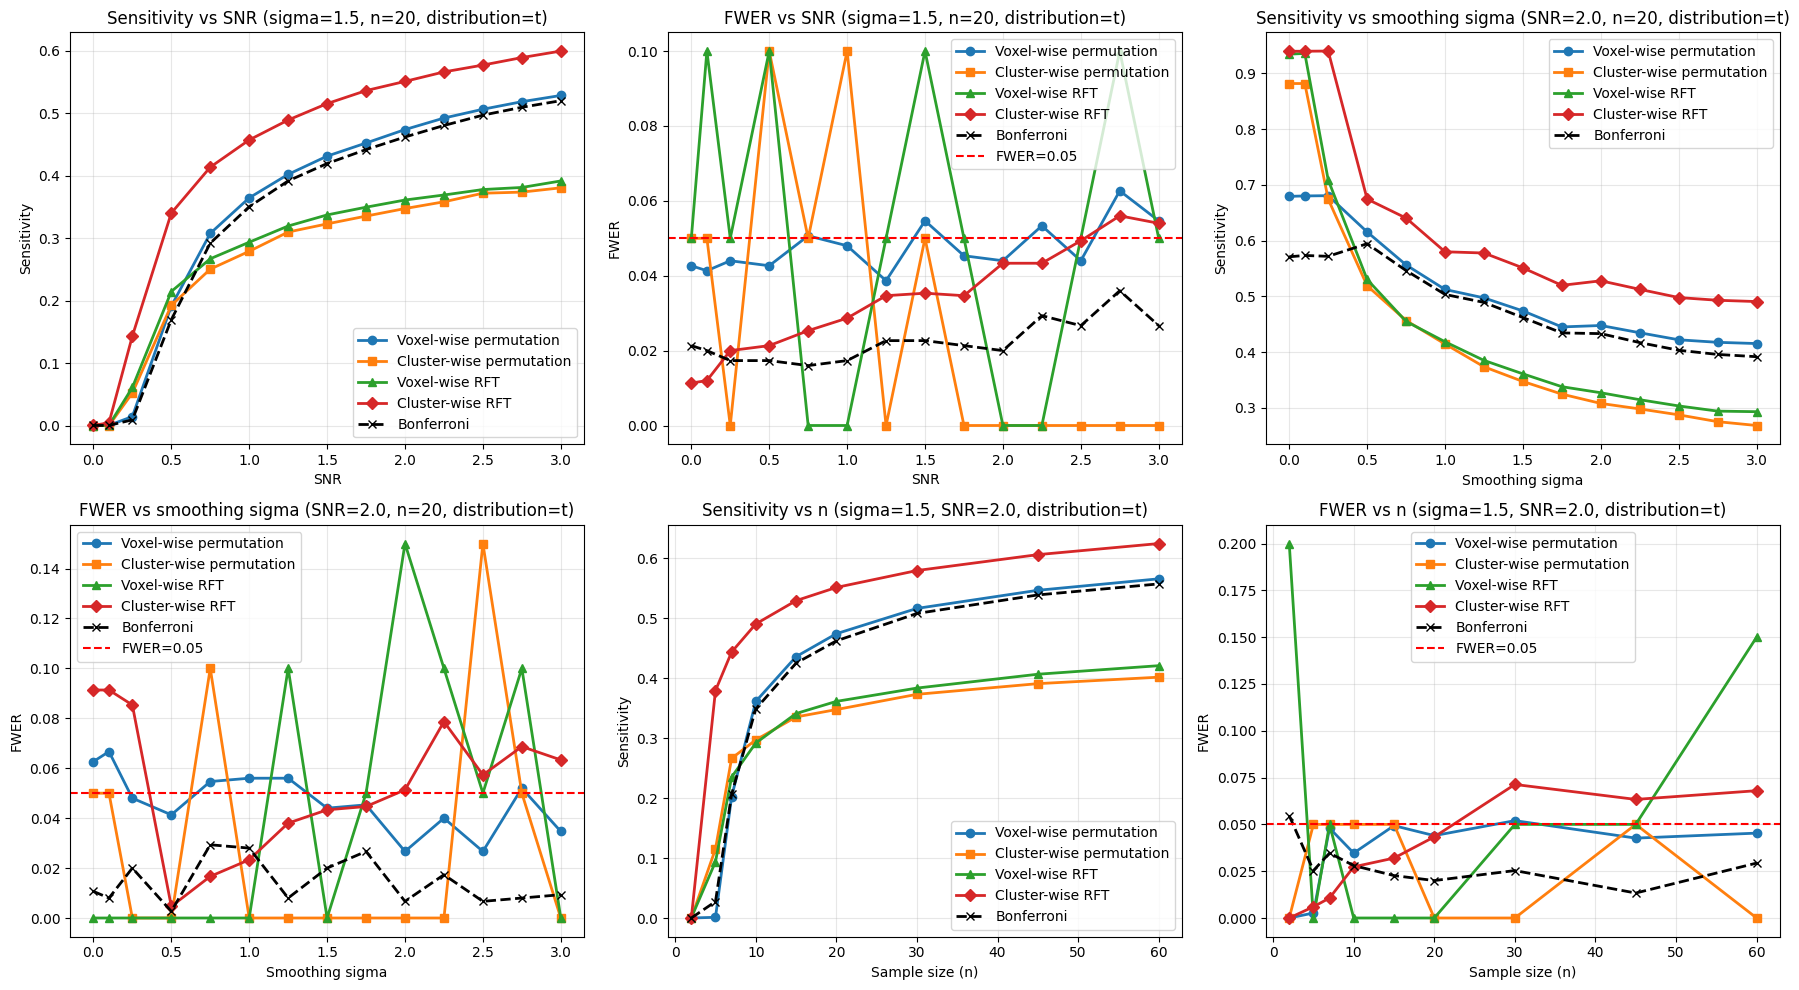

In [11]:
import importlib
import plotters as pl
importlib.reload(pl)

pl.plot_all_method_curves(final_metrics_df_t, sigma=1.5, snr_val=2.0, n_val=20)

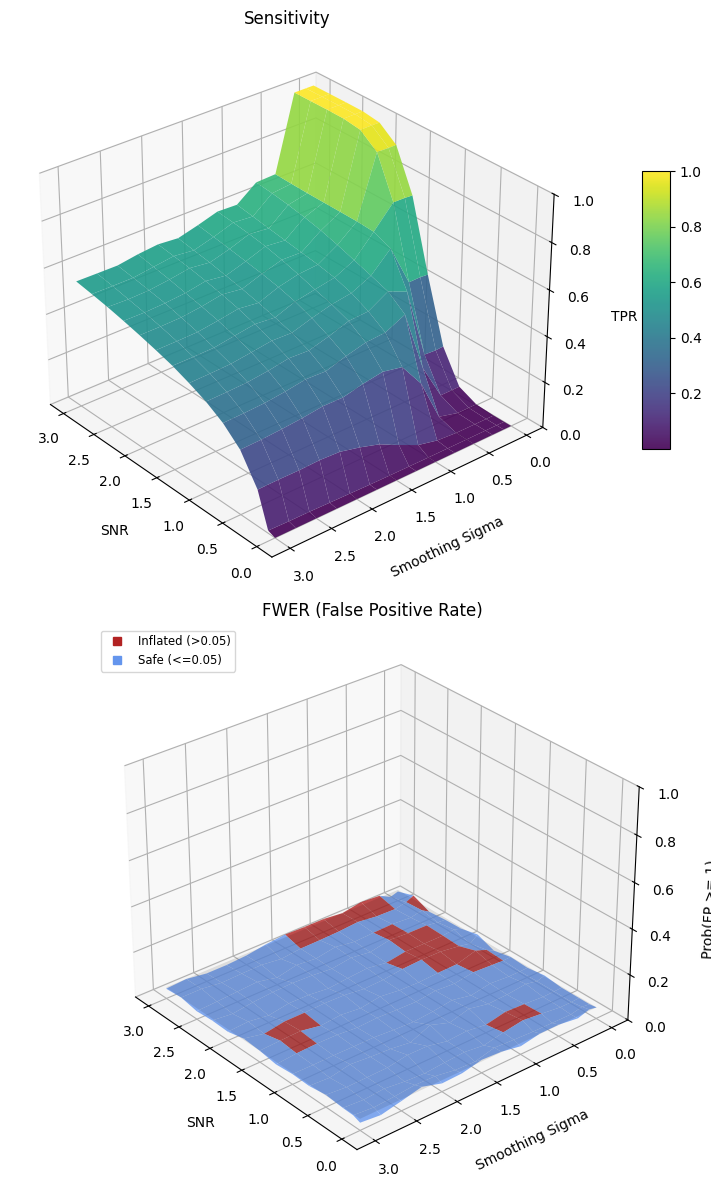

In [12]:
sens_mat, fwer_mat = hf.reconstruct_metric_matrices(df = vv_prm_df_n, n_value = 20, sigma_levels = test_sigmas, snr_levels = test_snrs, method = "Voxel-wise permutation")
pl.plot_3d_surfaces(test_snrs, test_sigmas, sens_mat, fwer_mat, elev=30, azim=140)